In [103]:
import os
from pathlib import Path

import contextily as cx
import matplotlib as mpl
import matplotlib.colors as mcol
import matplotlib.patches as mpatch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import rasterio as rio
import rasterio.plot as rio_plot
import rasterio.windows as rio_windows
import seaborn as sns
from scipy.interpolate import make_smoothing_spline

In [2]:
ghsl_path = Path(os.environ["GHSL_PATH"])
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [37]:
season_name_map = {"summer": "Verano", "winter": "Invierno"}

In [54]:
ZONE = "CRI+San José"
IN_SOUTH_AMERICA = True

# Rasters

## Seasonal

In [90]:
temp_season = {}
transform_season = {}

for season in ["summer", "winter"]:
    if IN_SOUTH_AMERICA and season == "summer":
        to_read = "winter"
    else:
        to_read = "summer"

    if IN_SOUTH_AMERICA and season == "winter":
        to_read = "summer"
    else:
        to_read = "winter"
    with rio.open(
        out_path
        / "raster_zone_download"
        / "temp_seasonal_download"
        / ZONE
        / f"2024_{to_read}.tif",
    ) as ds:
        transform_season[season] = ds.transform
        temp_season[season] = ds.read(1)
        extent = ds.bounds

map_offset = 0.04

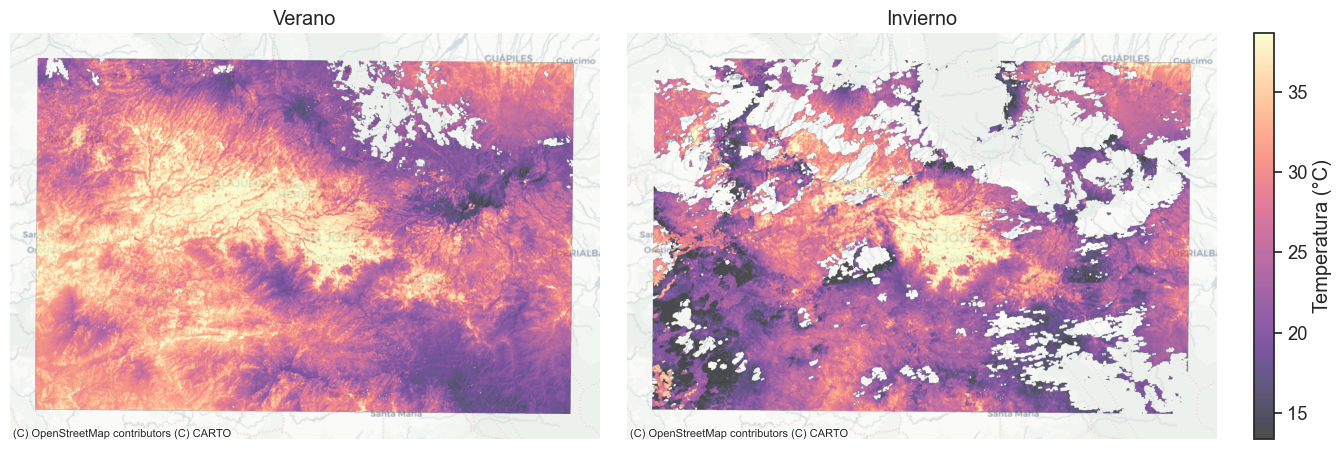

In [ ]:
sns.set_theme(style="ticks", font_scale=1.2)

summer_data = temp_season["summer"]
summer_data = summer_data[~np.isnan(summer_data)]

winter_data = temp_season["winter"]
winter_data = winter_data[~np.isnan(winter_data)]

vmin = np.min([np.quantile(summer_data, 0.03), np.quantile(winter_data, 0.03)])

vmax = np.max([np.quantile(summer_data, 0.97), np.quantile(winter_data, 0.97)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), width_ratios=(1, 1.25))
for season, ax in zip(["summer", "winter"], axes.flat):
    ax.set_xlim(extent.left - map_offset, extent.right + map_offset)
    ax.set_ylim(extent.bottom - map_offset, extent.top + map_offset)
    ax.axis("off")
    cx.add_basemap(
        ax,
        crs="EPSG:4326",
        source=cx.providers.CartoDB.Positron,
    )
    im_hidden = ax.imshow(
        temp_season[season],
        vmin=vmin,
        vmax=vmax,
        cmap="magma",
        alpha=0.7,
    )
    rio_plot.show(
        temp_season[season],
        transform=transform_season[season],
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap="magma",
        alpha=0.7,
    )
    ax.set_title(season_name_map[season])

fig.colorbar(im_hidden, label="Temperatura (°C)")
fig.tight_layout()
fig.savefig("./fig/seasonal_temp.jpg", bbox_inches="tight", dpi=300)

## SUHII

In [98]:
with rio.open(out_path / "raster_zone_download" / "suhi" / ZONE / "2024.tif") as ds:
    suhi_latlon = ds.read(1).squeeze()
    transform = ds.transform

with rio.open(
    out_path / "raster_zone_download" / "suhi_categorical" / ZONE / "2024.tif",
) as ds:
    suhi_cat_latlon = ds.read(1).squeeze().astype(float)
    suhi_cat_latlon[suhi_cat_latlon == -99] = np.nan

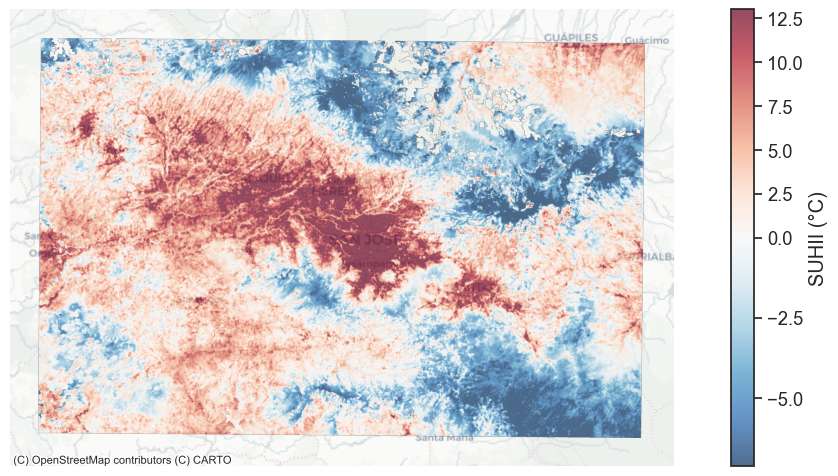

In [94]:
temp_data = suhi_latlon[~np.isnan(suhi_latlon)]
norm = mcol.TwoSlopeNorm(
    vmin=np.quantile(temp_data, 0.03),
    vcenter=0,
    vmax=np.quantile(temp_data, 0.97),
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(extent.left - map_offset, extent.right + map_offset)
ax.set_ylim(extent.bottom - map_offset, extent.top + map_offset)
ax.axis("off")
cx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=cx.providers.CartoDB.Positron,
)

im_hidden = ax.imshow(suhi_latlon, norm=norm, cmap="RdBu_r", alpha=0.7)
rio_plot.show(
    suhi_latlon,
    transform=transform,
    cmap="RdBu_r",
    norm=norm,
    alpha=0.7,
    ax=ax,
)
fig.colorbar(im_hidden, label="SUHII (°C)")
fig.tight_layout()
fig.savefig("./fig/suhi.jpg", bbox_inches="tight", dpi=300)

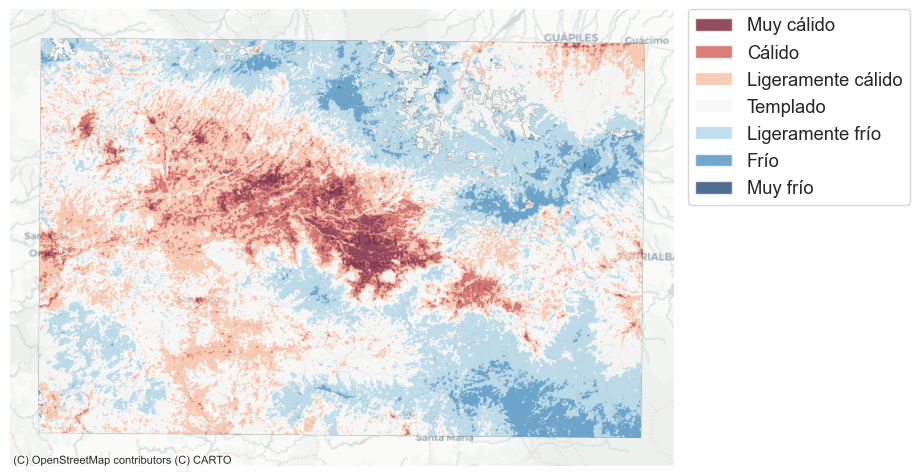

In [138]:
cmap = mpl.colormaps["RdBu_r"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(extent.left - map_offset, extent.right + map_offset)
ax.set_ylim(extent.bottom - map_offset, extent.top + map_offset)
ax.axis("off")
cx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=cx.providers.CartoDB.Positron,
)

im_hidden = ax.imshow(suhi_latlon, norm=norm, cmap="RdBu_r", alpha=0.7)
rio_plot.show(suhi_cat_latlon, transform=transform, cmap="RdBu_r", alpha=0.7, ax=ax)
ax.legend(
    handles=[
        mpatch.Patch(facecolor=cmap(0.9999), label="Muy cálido", alpha=0.7),
        mpatch.Patch(facecolor=cmap(5 / 6), label="Cálido", alpha=0.7),
        mpatch.Patch(facecolor=cmap(4 / 6), label="Ligeramente cálido", alpha=0.7),
        mpatch.Patch(facecolor=cmap(3 / 6), label="Templado", alpha=0.7),
        mpatch.Patch(facecolor=cmap(2 / 6), label="Ligeramente frío", alpha=0.7),
        mpatch.Patch(facecolor=cmap(1 / 6), label="Frío", alpha=0.7),
        mpatch.Patch(facecolor=cmap(0), label="Muy frío", alpha=0.7),
    ],
    bbox_to_anchor=(1.37, 1.02),
)
fig.tight_layout()
fig.savefig("./fig/suhi_cat.jpg", bbox_inches="tight", dpi=300)

# Temp

In [69]:
transforms = {}

with rio.open("./reprojected/costa_rica/suhi.tif") as ds:
    bounds = ds.bounds
    temp = ds.read(1).squeeze()
    transforms["suhi"] = ds.transform

with rio.open("./reprojected/costa_rica/suhi_categorical.tif") as ds:
    temp_categorical = ds.read(1).squeeze().astype(float)
    temp_categorical[temp_categorical == -99] = np.nan
    transforms["suhi_cat"] = ds.transform

with rio.open(ghsl_path / "POP_100" / "2020.tif") as ds:
    window = rio_windows.from_bounds(*bounds, ds.transform)
    pop = ds.read(1, window=window).squeeze()
    pop[pop == ds.nodata] = np.nan
    transforms["pop"] = ds.transform

In [5]:
step = 0.5
df = (
    pd.DataFrame(
        zip(temp.flatten(), pop.flatten(), strict=False),
        columns=["temp", "pop"],
    )
    .groupby("temp")
    .agg({"pop": "sum"})
    .reset_index()
    .sort_values("temp")
    .assign(cum_pop=lambda df: df["pop"].cumsum())
    .assign(
        temp_cut=lambda df: pd.cut(
            df["temp"],
            bins=np.arange(df["temp"].min(), df["temp"].max() + step, step),
            include_lowest=True,
        ),
    )
    .groupby("temp_cut")
    .agg(
        {
            "temp": "mean",
            "pop": "sum",
        },
    )
    .assign(cum_pop=lambda df: df["pop"].cumsum())
    .query("cum_pop > 0")
    .dropna(subset=["temp", "cum_pop"])
)

C:\Users\lain\AppData\Local\Temp\ipykernel_9740\906174031.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("temp_cut")


In [6]:
spline = make_smoothing_spline(df["temp"].to_numpy(), df["cum_pop"].to_numpy())
cdf = spline(df["temp"])
pdf = spline.derivative()(df["temp"])

(-1.0, 23.0)

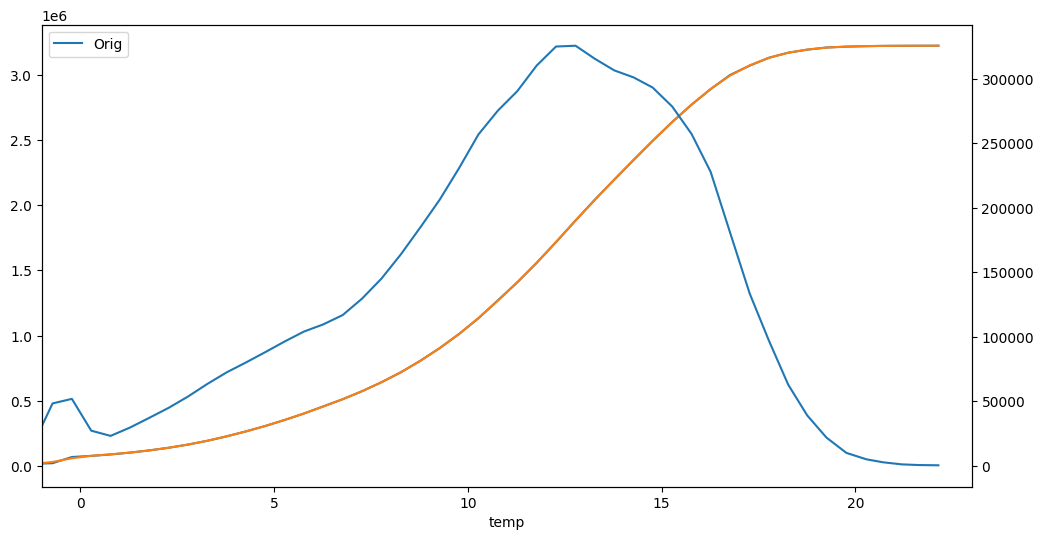

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()
df.plot(x="temp", y="cum_pop", ax=ax, label="Orig")
ax.plot(df["temp"], cdf, label="CDF")
ax2.plot(df["temp"], pdf, label="PDF")
ax.set_xlim(-1, 23)

# Categorical

In [129]:
df_categorical = (
    pd.DataFrame(
        zip(temp_categorical.flatten(), pop.flatten(), strict=False),
        columns=["temp_cat", "pop"],
    )
    .groupby("temp_cat")
    .agg({"pop": "sum"})
    .reset_index()
    .assign(
        temp_cat=lambda df: df["temp_cat"].map(
            {
                -3: "Muy frío",
                -2: "Frío",
                -1: "Ligeramente frío",
                0: "Templado",
                1: "Ligeramente cálido",
                2: "Cálido",
                3: "Muy cálido",
            },
        ),
    )
)

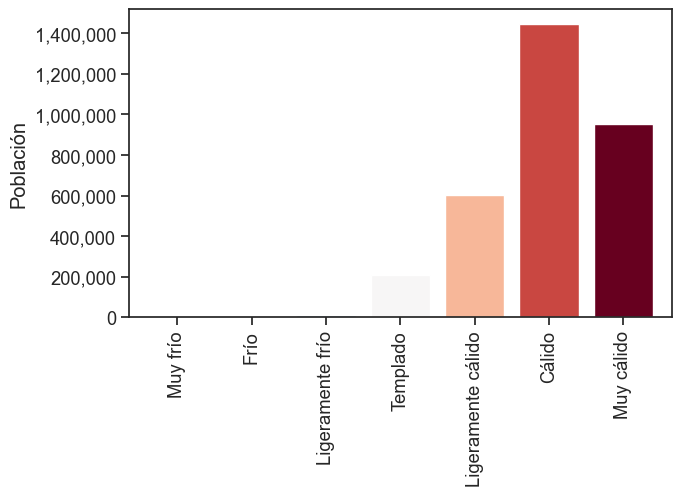

In [136]:
sns.set_theme(style="ticks", font_scale=1.2)

cmap = mpl.colormaps["RdBu_r"]

fig, ax = plt.subplots(figsize=(7, 4))
df_categorical.plot.bar(
    x="temp_cat",
    y="pop",
    color=cmap(np.linspace(0, 1, 7)),
    legend=False,
    width=0.8,
    ax=ax,
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("")
ax.set_ylabel("Población")
fig.savefig("./fig/pop_by_temp_cat.jpg", bbox_inches="tight", dpi=300, transparent=True)